## Lab - Using Interpretable Features for Model Debugging

In our lecture on interpretable features, you learned about the importance of using interpretable features for interpretable models. As we talked about, one of the benefits of interpretable machien learning is it makes it easier to identify the source of a problem with a deployed model.

In this lab, we'll be working with a modified version of the Ames Housing Dataset (CITE). In this dataset, each row represents a single house in Ames Iowa, and our model is traiend to predict the final sale price of the house. 

In our hypothetical scenario, a real estate agent has deployed a model to help they set the initial sale price houses newly on the market. However, despite decent train and test scores during model training, the agent has found that the house predictions are terrible in the real world. They suspect something went wrong with the data, and want to use methods from *XAI* (explainable AI) to identify the problem.

Your task will be to try to find the issue with the data. You will try transforming the data in different ways to train multiple models with different levels of *feature interpretability*. There are **two mistakes** intentionally added to the dataset. 

# Result summary

- The data included the variable FinalBid, which is kinda sorta cheating when you try and predict the sale price
- The variable OverallQual was flipped in both the training and the test data. For this reason, the performance was good on the test set, but the model generalizes a lot worse than it should
- Automatic variable selection gave a bit crazy results. Due to software issues I was not able to look into it properly

### Data Setup

Run the cells below to install libraries, load in the (flawed) dataset, and take an initial look at the data. **After running the first (pip install) cell, make sure to restart your kernel by using Kernel -> Restart in the toolbar, the continue running from the second cell.**

In [ ]:

%pip install featuretools
%pip install pandas
%pip install numpy==1.23.5
%pip install lightgbm==3.3.5
%pip install shap

  Using cached pandas-2.3.3-cp311-cp311-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (91 kB)
  Using cached numpy-2.4.1-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
Using cached pandas-2.3.3-cp311-cp311-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (12.8 MB)
Using cached numpy-2.4.1-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.7 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.23.5
    Uninstalling numpy-1.23.5:
      Successfully uninstalled numpy-1.23.5
  Attempting uninstall: pandas
    Found existing installation: pandas 1.5.3
    Uninstalling pandas-1.5.3:
      Successfully uninstalled pandas-1.5.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.57.1 requires numpy<1.25,>=1.21, but you have numpy 2.4.1 which is incompatible.
pyreal 0.4.10 requires numpy<2.0

In [ ]:
import pandas as pd
import numpy as np
import lightgbm
from pyreal.transformers import OneHotEncoder, DataFrameWrapper, fit_transformers, run_transformers
import matplotlib.pyplot as plt

def one_hot_encode(X_train, X_test):
    categorical_features = X_train.select_dtypes(exclude=[np.number]).columns
    ohe = OneHotEncoder(columns=categorical_features)
    
    ohe.fit(pd.concat((X_train, X_test), axis=0))

    return ohe.transform(X_train), ohe.transform(X_test)

def fit_model(X_train, y_train):
    return lightgbm.LGBMRegressor().fit(X_train, y_train)

train_data = pd.read_csv("train_data.csv")
test_data = pd.read_csv("test_data.csv")

y_train = train_data.SalePrice
print("FinalBid" in train_data.columns)

X_train = train_data.drop("FinalBid", axis=1)
print("FinalBid" in X_train.columns)

X_train = X_train.drop("SalePrice", axis=1)
corrmat = train_data.corr(numeric_only=True).reset_index()

#print(corrmat.sort_values("SalePrice").head(20))
#print(np.corrcoef(train_data["SalePrice"], train_data["FinalBid"]))
#print(corrmat.sort_values("SalePrice").tail(20))
y_test = test_data.SalePrice
X_test = test_data.drop("FinalBid", axis=1)
X_test = X_test.drop("SalePrice", axis=1)

X_train_model, X_test_model = one_hot_encode(X_train, X_test)
feature_df = pd.read_csv("feature_descriptions.csv") # includes information about features
#print(feature_df[feature_df.name == "FinalBid"].to_dict())
#feature_df = feature_df[feature_df.name != "FinalBid"]
feature_df[feature_df.name == "FinalBid"].to_dict()

True
False


{'name': {126: 'FinalBid'},
 'description': {126: 'Final bid price placed on house before accepted sale'},
 'category': {126: 'general'},
 'type': {126: 'numeric'}}

Looking at the shap values, I noticed that FinalBid 

### Generating Explanations

To generate explanations throughout this lab, we will be using the popular explanation library [shap](https://shap.readthedocs.io/en/latest/). SHAP is a *model agnostic* explanation tool, meaning it can be used to explain any ML model, regardless of architecture --- however, as we will see, its explanations are less than useful when using uninterpretable features.

The shap library offers many different (plotting options)[https://shap.readthedocs.io/en/latest/api_examples.html#plots], you can try multiple out to see what works best for your task. Some plots provide *local explantions*, which explain the logic behind a single prediction. For this lab, you will be working with *global explanations*, which explain the model's logic overall. 

As a start, we recommend you try the **beeswarm** plot. This chart lists the feature the model considers most important on top, with reducing importance going down the y-axis. Each point represents a line in the dataset, with the color representing the value of the feature. The SHAP impact value, on the x-axis represents how much that feature value contributed to the model prediction. A higher value along the x-axis means that feature was highly positively correlated with the model prediction, while a lower value means it was negatively correlated. A SHAP value of zero means that feature value had no effect on the model prediction.

For example, in the sample visualization below, higher median income and lower populations in house blocks tends to result in higher house prices (which makes sense!) 

![example explanation](example_explanation.png)

Run the cell below for two helper functions that will get you started on generating explanations.

In [ ]:
#X_train_pca = pd.DataFrame(pca.transform(imputer.transform(X_train_std)), columns=pca.get_feature_names_out())
#X_test_pca = pd.DataFrame(pca.transform(imputer.transform(X_test_std)), columns=pca.get_feature_names_out())
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
scaler = DataFrameWrapper(StandardScaler())

X_train_std = scaler.fit_transform(X_train_model)
X_test_std = scaler.transform(X_test_model)
print(type(X_train_std))
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
imputer.fit(X_train_std)
X_train_std_imp = imputer.transform(X_train_std)
print(X_train_std_imp.shape)
print(X_train.columns)
X_train_plain = pd.DataFrame(X_train_std_imp, columns=X_train_model.columns)
print(sorted(list(set(X_train_model.columns))))
model_plain = fit_model(X_train_plain, y_train)

print("R^2 Score (all variables): %.3f" % model_plain.score(imputer.transform(X_test_std), y_test))


<class 'pandas.core.frame.DataFrame'>
(1237, 254)
Index(['LotFrontage', 'LotArea', 'Street', 'LotShape', 'Utilities',
       'LandSlope', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'HeatingQC', '1stFlrSF',
       '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath',
       'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu',
       'GarageYrBlt', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond',
       'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch',
       'ScreenPorch', 'PoolArea', 'PoolQC', 'MiscVal', 'YrSold', 'MSSubClass',
       'MSZoning', 'Alley', 'LandContour', 'LotConfig', 'Neighborhood',
       'Condition1', 'Condition2', 'BldgType', 'HouseSty

No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


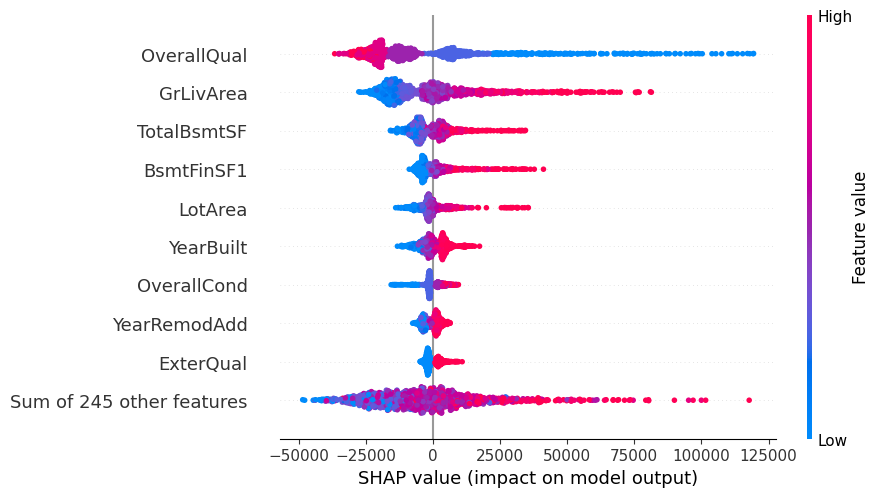

In [116]:
explain(model_plain, X_train_plain)

For some reason, high overall quality predicts a low price. This is probably a data preprocessing error, maybe the signs got flipped.

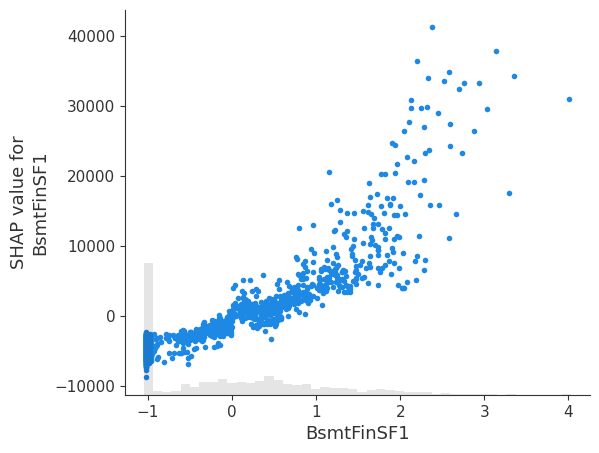

In [129]:
explain_feature(model_plain, X_train_plain, "BsmtFinSF1")

In [96]:
import shap

def explain(model, X_train):
    """
    Explain a model with a beeswarm plot. 
    
    model: a machine learning model
    X_train: a dataset of valid inputs to model
    """
    explainer = shap.explainers.Tree(model, X_train)
    shap_values = explainer(X_train)

    shap.plots.beeswarm(shap_values, max_display=10)

def explain_feature(model, X_train, feature_name):
    """
    Generate an explanation for the impact of a specific 
    feature on model predictions.
    
    model: a machine learning model
    X_train: a dataset of valid inputs to model
    feature_name: string, the name of a feature to investigate
    """
    explainer = shap.explainers.Tree(model, X_train)
    shap_values = explainer(X_train)

    shap.plots.scatter(shap_values[:, feature_name])

### Feature Transforms 1: PCA

We will begin by running a [PCA (Principle Component Analysis)](https://builtin.com/data-science/step-step-explanation-principal-component-analysis) on the data. Run the cell below to standardize and PCA transform the data, and train a light GBM model. Note the performance (given as an [R^2](https://www.geeksforgeeks.org/ml-r-squared-in-regression-analysis/) score).

In [117]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
scaler = DataFrameWrapper(StandardScaler())

X_train_std = scaler.fit_transform(X_train_model)
X_test_std = scaler.transform(X_test_model)
print(type(X_train_std))
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
imputer.fit(X_train_std)
X_train_std_imp = imputer.transform(X_train_std)

pca = PCA(n_components=0.95)
pca.fit(X_train_std_imp)

X_train_pca = pd.DataFrame(pca.transform(imputer.transform(X_train_std)), columns=pca.get_feature_names_out())
X_test_pca = pd.DataFrame(pca.transform(imputer.transform(X_test_std)), columns=pca.get_feature_names_out())

model_pca = fit_model(X_train_pca, y_train)

print("Number of PCA components used: %i" % pca.n_components_)
print("R^2 Score (PCA): %.3f" % model_pca.score(X_test_pca, y_test))


<class 'pandas.core.frame.DataFrame'>
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001412 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 39270
[LightGBM] [Info] Number of data points in the train set: 1237, number of used features: 154
[LightGBM] [Info] Start training from score 180635.625707
Number of PCA components used: 154
R^2 Score (PCA): 0.854


In the cell below, use the explanation helper functions (or others from the shap library/other explanation libraries you may be interested in trying) to generate some explanations of the model's prediction. Think about what additional steps you may need to take to identify the source of poor performance. 

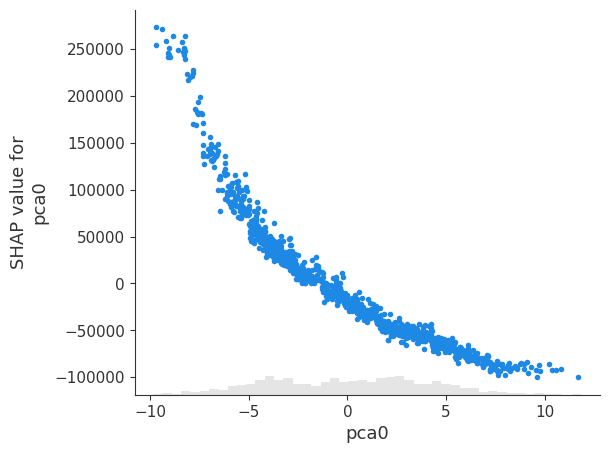

In [118]:
# Generate an explanation of the PCA model, and see if you can identify the data flaw
explain_feature(model_pca, X_train_pca, "pca0")

No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


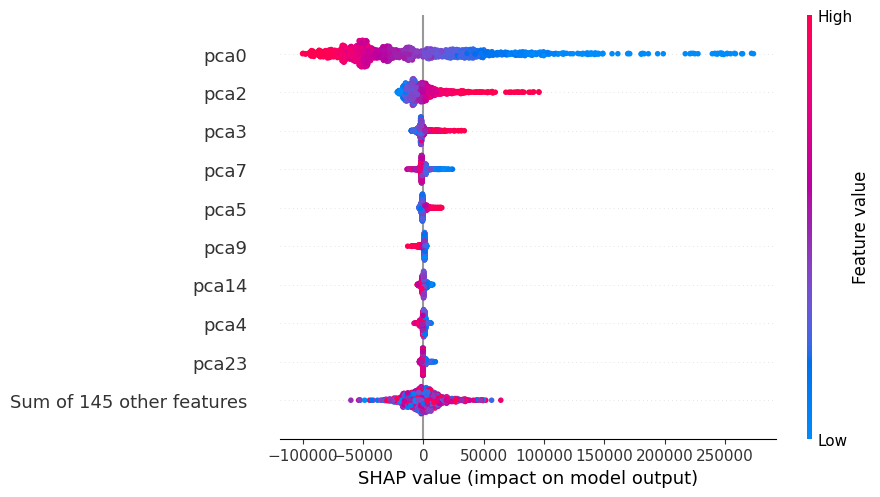

In [119]:
explain(model_pca, X_train_pca)

### Feature Transforms 2: Automatic Feature Engineering

Next, we will try a different set of transformations using an automatic feature engineering tool - [Featuretools](https://www.featuretools.com/). This is a powerful library that makes it possible to dry hundreds of feature engineering options with just a few lines of code. There are many situations were this is a very useful process - but as we'll see below, automatic feature engineering without care can lead to less interpretable features.

Run the cell below to generate a significantly larger dataset of engineered features. This process may be slow - you can load in the pretrained results of the engineering process by setting `load_pretrained = True`

In [140]:
import featuretools as ft

load_pretrained = False

def make_entity_set(X):
    es = ft.EntitySet(id="houses")
    
    X_with_ind = X.copy()
    X_with_ind['index'] = X_with_ind.index
    
    es = es.add_dataframe(
      dataframe_name="houses",
      dataframe=X_with_ind,
      index="index",
    )
    
    return es

def feature_engineer(es, num_to_engineer=15, primitives=None):
    # To avoid large computation times, we 
    ignore_features = list(feature_df["name"][num_to_engineer:])
    
    if primitives is None:
        # To avoid large computation times, we'll just work with a truncated set of options
        primitives = ['multiply_numeric', "greater_than", "divide_by_feature"]
  
    feature_matrix, feature_defs = ft.dfs(
        entityset=es,
        target_dataframe_name="houses",
        trans_primitives=primitives,
        ignore_columns={"houses": ignore_features},
        max_depth=1,
        max_features=1000
    )
    
    return feature_matrix, feature_defs

if load_pretrained:
    X_train_ft = pd.read_csv("X_train_ft.csv")
    X_train_ft["Alley"] = pd.to_numeric(X_train_ft["Alley"], errors="coerce")
    X_test_ft = pd.read_csv("X_test_ft.csv")

else:
    print("Starting deep feature synthesis on training data")
    X_train_ft, feature_defs = feature_engineer(make_entity_set(X_train))

    print("Starting feature engineering on testing data")
    X_test_ft = ft.calculate_feature_matrix(feature_defs, make_entity_set(X_test))

print(X_test_ft["Alley"])
X_train_ft_model, X_test_ft_model = one_hot_encode(X_train_ft, X_test_ft)

print(X_train_ft_model["Alley"])

model_ft = fit_model(X_train_ft_model, y_train)
print("R2 Score (Featuretools):", model_ft.score(X_test_ft_model, y_test))

Starting deep feature synthesis on training data


Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected,

Starting feature engineering on testing data


Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected,

index
0      <NA>
1      <NA>
2      <NA>
3      <NA>
4      <NA>
       ... 
214    <NA>
215    <NA>
216    <NA>
217    <NA>
218    <NA>
Name: Alley, Length: 219, dtype: Int64
index
0       <NA>
1       <NA>
2       <NA>
3       <NA>
4       <NA>
        ... 
1232    <NA>
1233    <NA>
1234    <NA>
1235    <NA>
1236    <NA>
Name: Alley, Length: 1237, dtype: Int64
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003752 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 13419
[LightGBM] [Info] Number of data points in the train set: 1237, number of used features: 597
[LightGBM] [Info] Start training from score 180635.625707
R2 Score (Featuretools): 0.8162083933510846


Once again, try generating explanations on the generated data, and see if you can guess at the flaw in the data. 

In [142]:
# Generate explanations here
#X_train_ft_model
#explain(model_ft, X_train_ft_model)
X_train_ft_model

,MSSubClass_SC120,MSSubClass_SC160,MSSubClass_SC180,MSSubClass_SC190,MSSubClass_SC20,MSSubClass_SC30,MSSubClass_SC40,MSSubClass_SC45,MSSubClass_SC50,MSSubClass_SC60,...,OverallQual * Street,OverallQual * Utilities,OverallQual * YearBuilt,OverallQual * YearRemodAdd,Street * Utilities,Street * YearBuilt,Street * YearRemodAdd,Utilities * YearBuilt,Utilities * YearRemodAdd,YearBuilt * YearRemodAdd
index,,,,,,,,,,,,,,,,,,,,,
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,2.0,4.0,2006.0,2006.0,8.0,4012.0,4012.0,8024.0,8024.0,4024036.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,14.0,28.0,13573.0,13650.0,8.0,3878.0,3900.0,7756.0,7800.0,3781050.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,10.0,20.0,9705.0,9750.0,8.0,3882.0,3900.0,7764.0,7800.0,3784950.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,12.0,24.0,11772.0,11772.0,8.0,3924.0,3924.0,7848.0,7848.0,3849444.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,8.0,16.0,7904.0,7904.0,8.0,3952.0,3952.0,7904.0,7904.0,3904576.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1232,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,8.0,16.0,7764.0,7800.0,8.0,3882.0,3900.0,7764.0,7800.0,3784950.0
1233,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,14.0,28.0,13370.0,13650.0,8.0,3820.0,3900.0,7640.0,7800.0,3724500.0
1234,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,6.0,12.0,6015.0,6018.0,8.0,4010.0,4012.0,8020.0,8024.0,4022030.0


### Basic Feature Transformations

In many datasets, complex feature engineering does not offer a lot (or any!) boost in model performance, while lowering the interpretability of features. In this dataset, we happened to be given data already turned into useful features. Again, we will train a model on a set of features. Then, try generating some explanations and see if you can guess at the data flaw.

In [12]:
model_orig = fit_model(X_train_std, y_train)
print("R2 Score (Original):", model_orig.score(X_test_std, y_test))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001650 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3609
[LightGBM] [Info] Number of data points in the train set: 1237, number of used features: 166
[LightGBM] [Info] Start training from score 180635.625707
R2 Score (Original): 0.9238530996352583


In [31]:
# Generate explanations here


### Boosting Feature Interpretability

You may have already guessed at one or both flaws in the data based on the explanations generated above, but we can make explanations that are even more immedietely readable by using a library that factors in feature interpretability like [Pyreal](https://dtail.gitbook.io/pyreal/). The example below shows the setup for a Global Feature Importance explanation, which provides one overall importance value per feature to show you which features are most used by the model generally. 

The explanation you generate in the cell below should help you identify one of the data flaws.

In [13]:
from pyreal.explainers import GlobalFeatureImportance, LocalFeatureContribution
from pyreal.utils.visualize import plot_top_contributors, swarm_plot

feature_descriptions = dict(zip(feature_df.name, feature_df.description))

categorical_features = X_train.select_dtypes(exclude=[np.number]).columns
ohe = OneHotEncoder(columns=categorical_features)
scaler = DataFrameWrapper(StandardScaler())

ohe.fit(pd.concat((X_train, X_test), axis=0))
scaler.fit(ohe.transform(X_train))

global_explainer = GlobalFeatureImportance(model_orig, x_train_orig=X_train, 
                                           e_algorithm="shap", transformers=[ohe, scaler], 
                                           feature_descriptions=feature_descriptions, 
                                           fit_on_init=True)

explanation = global_explainer.produce()
plot_top_contributors(explanation, n=10)

ModuleNotFoundError: No module named 'pyreal.utils.visualize'

Now, use the example above as well as additional documentation [here](https://dtail.gitbook.io/pyreal/getting-started/quickstart) to generate a Local Feature Contribution explanation, which will give you further information about the exact positive and negative contributions of each feature.

In [33]:
local_explainer = # your code here #

local_explanation, x_interpret = # your code here #

SyntaxError: invalid syntax (1082507576.py, line 1)

You can now look at multiple individual explanations individually using `plot_top_contributors`, or you may find it more useful to generate a swarm plot like the ones above using Pyreals [swarm_plot](https://sibyl-ml.dev/pyreal/api_reference/api/pyreal.utils.visualize.swarm_plot.html#pyreal.utils.visualize.swarm_plot) function.

In [ ]:
# your code here #

### Results

As you may have determined from the explanations above, the data has two flaws.

<details>
<summary><font color='blue'> Click to reveal solution </font></summary>The first is an example of **data leakage**, by including a feature for the bid price on houses sold in the past. We won't have access to the information for new houses on the market, so a model that relies heavily on this information will not be useful for setting the original house price.

The second was a mistake in the engineering of features, resulting in higher quality of housing materials leading to lower model predictions. If this mistake does not exist in new data coming in, we can expect model performance to decrease. 
</details>

### Bonus activity

If you'd like to get more experience with generating interpretable features, try finding a dataset on a topic you know a lot about. Generate features based on information you know is important, and then compare the explanations and performance to features generated automatically using a tool like the ones above.